# ANALISIS DATA AL/ML PACKAGES DARI PYPI SEP 2025 - MAR 2026

## Tujuan Bisnis
1. **Prediksi trajektori download package AI** Membangun model time-series (LSTM / Prophet / ARIMA) untuk memprediksi volume download harian package AI di masa depan, sehingga developer dan perusahaan dapat mengantisipasi lonjakan kebutuhan infrastruktur dan merencanakan dependency management secara proaktif.
2. **Identifikasi framework AI yang tumbuh paling cepat** Menganalisis tren pertumbuhan framework tag (PyTorch, LangChain, HuggingFace, AI Agents, dll.) dalam periode LLM era untuk memberikan rekomendasi berbasis data kepada tim engineering dalam pemilihan tech stack yang paling prospektif dan berkelanjutan.
3. **Kuantifikasi dampak era LLM terhadap ekosistem Python** Membandingkan kecepatan pertumbuhan download antara package LLM-era (llm_era_package = True, rilis 2023+) dengan package pre-LLM untuk mengukur secara empiris seberapa besar "LLM effect" mengubah pola adopsi package Python secara industri.
4. **Analisis pola harian dan mingguan** apakah ada efek liburan atau weekday/weekend pada volume download, yang dapat membantu tim marketing dan release management dalam merencanakan kampanye promosi atau jadwal rilis yang optimal.


## Import Library

In [ ]:
%pip install pandas seaborn numpy matplotlib statsmodels prophet scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import date, datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df = pd.read_csv("PyPI/pypi_ai_packages.csv", parse_dates=['date'])

df.head()


,package_name,date,year,month,week,download_type,downloads,version_latest,author,license,license_group,summary,keywords,requires_python,dependency_count,total_versions,first_release_date,age_days,llm_era_package,framework_tag,total_downloads,avg_daily_downloads,download_momentum_pct,home_page
0,accelerate,2025-09-22,2025,9,39,with_mirrors,578367,1.13.0,The Hugging Face team,Apache,Apache-2.0,Accelerate,deep learning,>=3.10.0,69,81,2020-10-30,1970,False,General AI/ML,114561902,58153.25,14.52,https://github.com/huggingface/accelerate
1,accelerate,2025-09-23,2025,9,39,with_mirrors,589253,1.13.0,The Hugging Face team,Apache,Apache-2.0,Accelerate,deep learning,>=3.10.0,69,81,2020-10-30,1970,False,General AI/ML,114561902,58153.25,14.52,https://github.com/huggingface/accelerate
2,accelerate,2025-09-24,2025,9,39,with_mirrors,552637,1.13.0,The Hugging Face team,Apache,Apache-2.0,Accelerate,deep learning,>=3.10.0,69,81,2020-10-30,1970,False,General AI/ML,114561902,58153.25,14.52,https://github.com/huggingface/accelerate
3,accelerate,2025-09-25,2025,9,39,with_mirrors,551276,1.13.0,The Hugging Face team,Apache,Apache-2.0,Accelerate,deep learning,>=3.10.0,69,81,2020-10-30,1970,False,General AI/ML,114561902,58153.25,14.52,https://github.com/huggingface/accelerate
4,accelerate,2025-09-26,2025,9,39,with_mirrors,540637,1.13.0,The Hugging Face team,Apache,Apache-2.0,Accelerate,deep learning,>=3.10.0,69,81,2020-10-30,1970,False,General AI/ML,114561902,58153.25,14.52,https://github.com/huggingface/accelerate


In [71]:
'''
to-do:
1. Download pattern monthly, weekly
2. Top 10 packages by download count
3. dataset trend, seasonality, cyclic pattern
4. data missing values 
5. data outliers 


'''

'\nto-do:\n1. Download pattern monthly, weekly\n2. Top 10 packages by download count\n3. dataset trend, seasonality, cyclic pattern\n4. data missing values \n5. data outliers \n\n\n'

# Data Preprocessing

## Cek Missing Values

In [72]:
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values)

Missing values:
package_name                 0
date                         0
year                         0
month                        0
week                         0
download_type                0
downloads                    0
version_latest               0
author                   46096
license                  31254
license_group                0
summary                   2360
keywords                 59624
requires_python          16502
dependency_count             0
total_versions               0
first_release_date           0
age_days                     0
llm_era_package              0
framework_tag                0
total_downloads              0
avg_daily_downloads          0
download_momentum_pct        0
home_page                19910
dtype: int64


## Insight Missing Values
- Terdapat missing value pada beberapa fitur seperti `author`, `license`, `summary`, dll. Namun, fitur-fitur tersebut tidak penting untuk analisis tren download, sehingga kita dapat mengabaikan missing value ini tanpa perlu melakukan imputation.

# Exploratory Data Analysis (EDA)

## Top Downloaded Packages

C:\Users\nunye\AppData\Local\Temp\ipykernel_24104\3436850545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_packages.values, y=top_packages.index, palette='viridis')


Text(0.5, 1.0, 'Top 15 Packages dari total download')

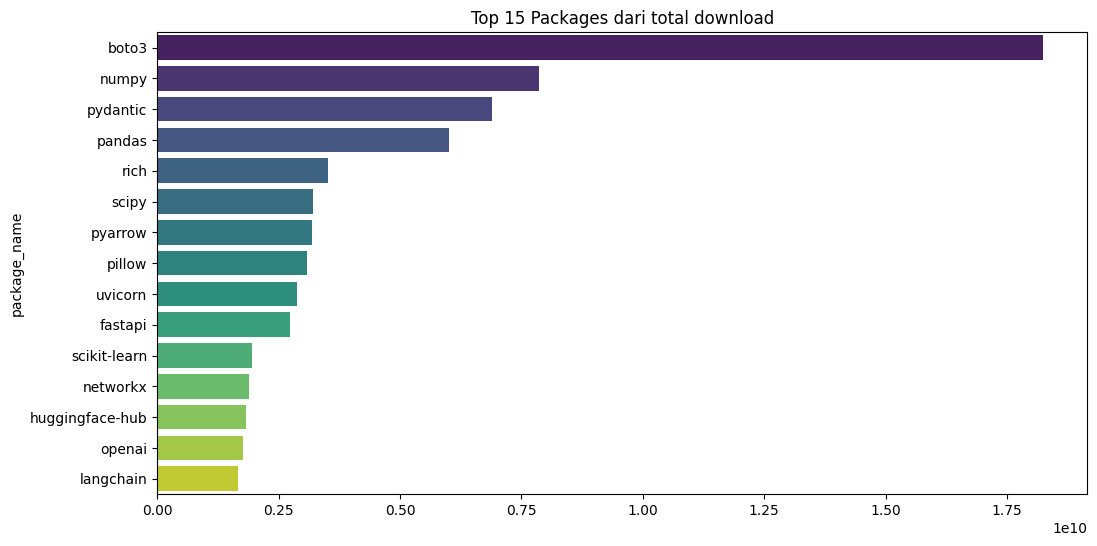

In [73]:
top_packages = df.groupby('package_name')['downloads'].sum().nlargest(15)
fig = plt.figure(figsize=(12,6))
sns.barplot(x=top_packages.values, y=top_packages.index, palette='viridis')
plt.title('Top 15 Packages dari total download')

#### Key Takeaways:
- Dari semua packages yang ada package `boto3` memiliki jumlah download terbanyak dengan jumlah lebih dari dua kali lipat jumlah download package kedua yaitu `numpy`, mengindikasikan dominasi yang kuat dari package AWS SDK untuk Python dalam ekosistem Python secara keseluruhan.
- Package `numpy` berada di posisi kedua dengan jumlah download yang sangat tinggi, menegaskan perannya sebagai library esensial untuk pengembangan AI/ML.

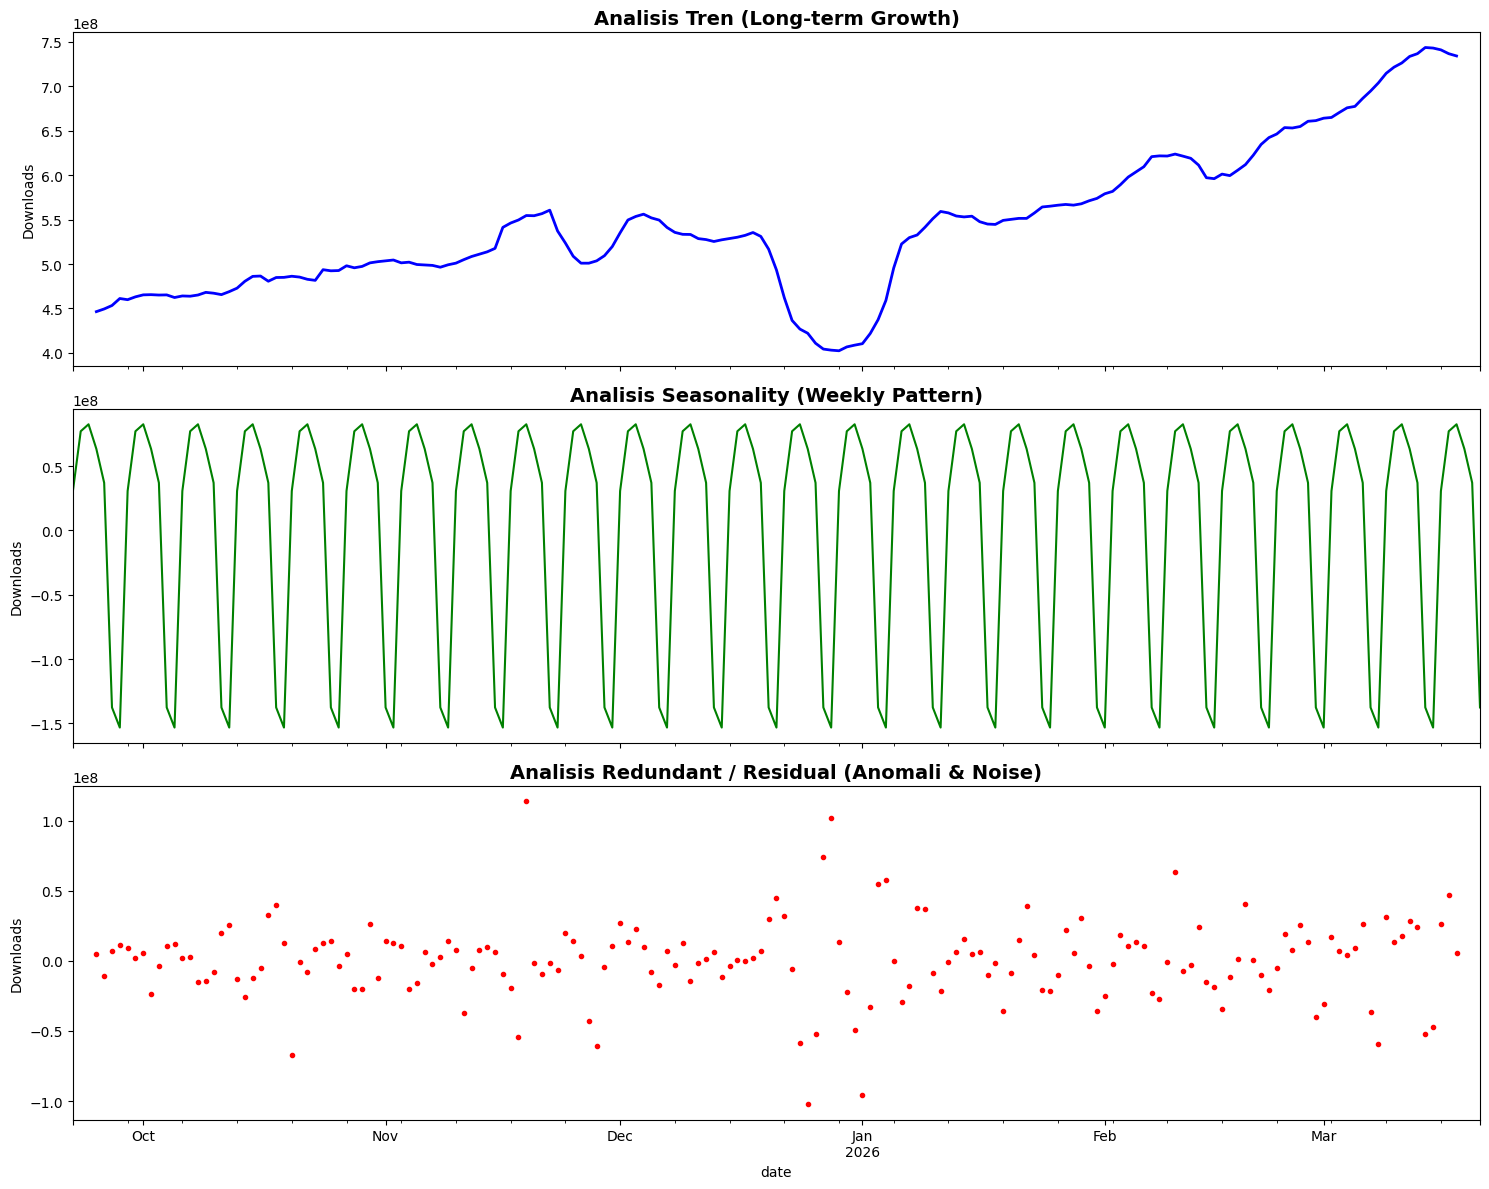

Jumlah baris duplikat: 0

Statistik Tren (Mean Download Harian):
count    1.810000e+02
mean     5.464609e+08
std      1.290124e+08
min      3.191433e+08
25%      4.444483e+08
50%      5.527281e+08
75%      6.230135e+08
max      8.611068e+08
Name: downloads, dtype: float64


In [74]:
daily_downloads = df.groupby('date')['downloads'].sum().reset_index()
daily_downloads.set_index('date', inplace=True)

result = seasonal_decompose(daily_downloads['downloads'], model='additive', period=7)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

result.trend.plot(ax=ax1, color='blue', linewidth=2)
ax1.set_title('Analisis Tren (Long-term Growth)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Downloads')

result.seasonal.plot(ax=ax2, color='green')
ax2.set_title('Analisis Seasonality (Weekly Pattern)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Downloads')

result.resid.plot(ax=ax3, color='red', style='.')
ax3.set_title('Analisis Redundant / Residual (Anomali & Noise)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Downloads')

plt.tight_layout()
plt.savefig('timeseries_decomposition.png')
plt.show()

duplicates = df.duplicated().sum()
duplicate_rows = df[df.duplicated()]

print(f"Jumlah baris duplikat: {duplicates}")
print("\nStatistik Tren (Mean Download Harian):")
print(daily_downloads['downloads'].describe())

#### Key Takeaways:
- **Analisis Tren**. Total download harian tumbuh signifikan yang mana pertumubuhan sekitar 450 juta pada September dan meningkat hingga 750 juta pada bulan Maret. Rata- rata download harian yaitu 546 juta. Dan terlihat adanya penurunan tajam di akhir Desember 2025 hingga awal Januari 2026 sebelum akhirnya melonjak kembali, ini membuktikan dampak libur Natal dan Tahun Baru pada aktivitas pengembang.
- **Analisis Seasonality**. Puncak unduhan terjadi pada hari kerja dan mencapai titik terendah setiap akhir pekan.


## Analisis Tren Harian

<Axes: xlabel='date', ylabel='downloads'>

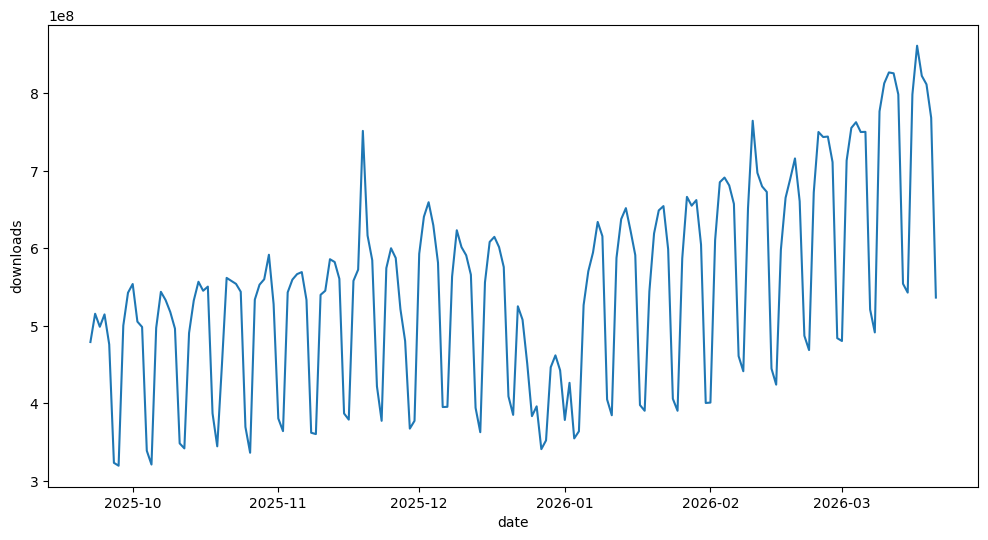

In [75]:
df['date'] = pd.to_datetime(df['date'])

if 'dayofweek' not in df.columns:
    df['dayofweek'] = df['date'].dt.dayofweek

daily_download = df.groupby(['date'])['downloads'].sum().reset_index()
daily_download.head(20)

fig = plt.figure(figsize=(12,6))
sns.lineplot(data=daily_download, x='date', y='downloads', color='#1f77b4')

#### Key Takeaways:
- Terdapat pola musiman yang jelas dalam tren download harian.
- Volume download cenderung lebih tinggi pada hari kerja dibandingkan dengan akhir pekan, menunjukkan bahwa banyak pengguna mungkin mengunduh package untuk keperluan pekerjaan atau proyek (sistem automasi) yang terkait dengan pekerjaan.
- Terdapat penurunan signifikan pada akhir desember, kemungkinan besar terkait dengan liburan akhir tahun, yang menunjukkan bahwa banyak pengguna atau sistem automasi mungkin tidak aktif dalam mengunduh package selama periode tersebut.

## Analisis Tren Mingguan

C:\Users\nunye\AppData\Local\Temp\ipykernel_24104\161379665.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_download, x='day_name', y='downloads', palette='viridis')


<Axes: xlabel='day_name', ylabel='downloads'>

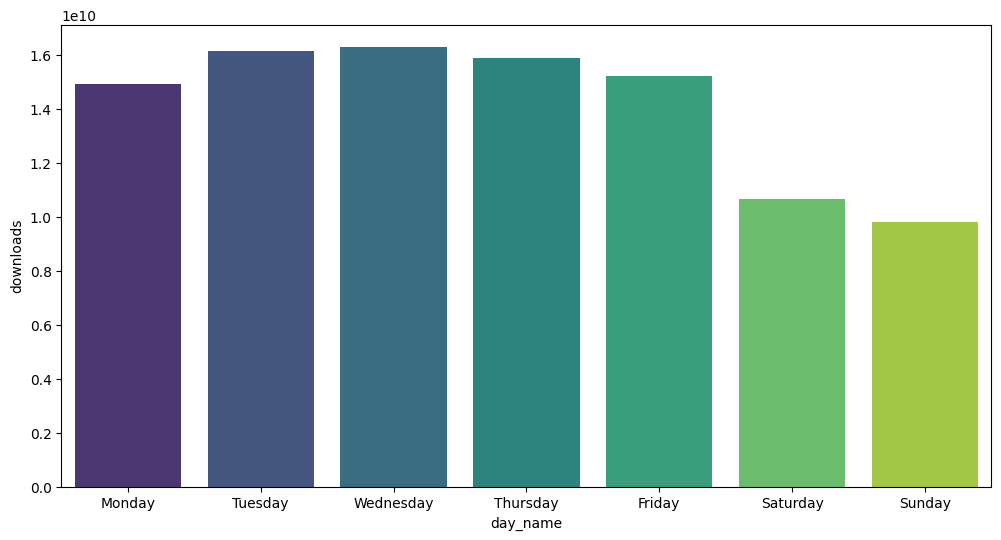

In [76]:
df['dayofweek_num'] = df['date'].dt.dayofweek
weekly_download = df.groupby('dayofweek_num')['downloads'].sum().reset_index()
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekly_download['day_name'] = weekly_download['dayofweek_num'].map(day_map)
plt.figure(figsize=(12,6))
sns.barplot(data=weekly_download, x='day_name', y='downloads', palette='viridis')

#### Key Takeaways:
- Terdapat pola musiman yang jelas dalam tren mingguan, dengan volume download yang lebih tinggi pada hari kerja dibandingkan dengan akhir pekan, mengindikasikan bahwa banyak pengguna mungkin mengunduh package untuk keperluan pekerjaan atau proyek (sistem automasi) yang terkait dengan pekerjaan.

## Analisa Framework Tag

C:\Users\nunye\AppData\Local\Temp\ipykernel_24104\1702915553.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_download, x='downloads', y='tag_list', palette='magma')


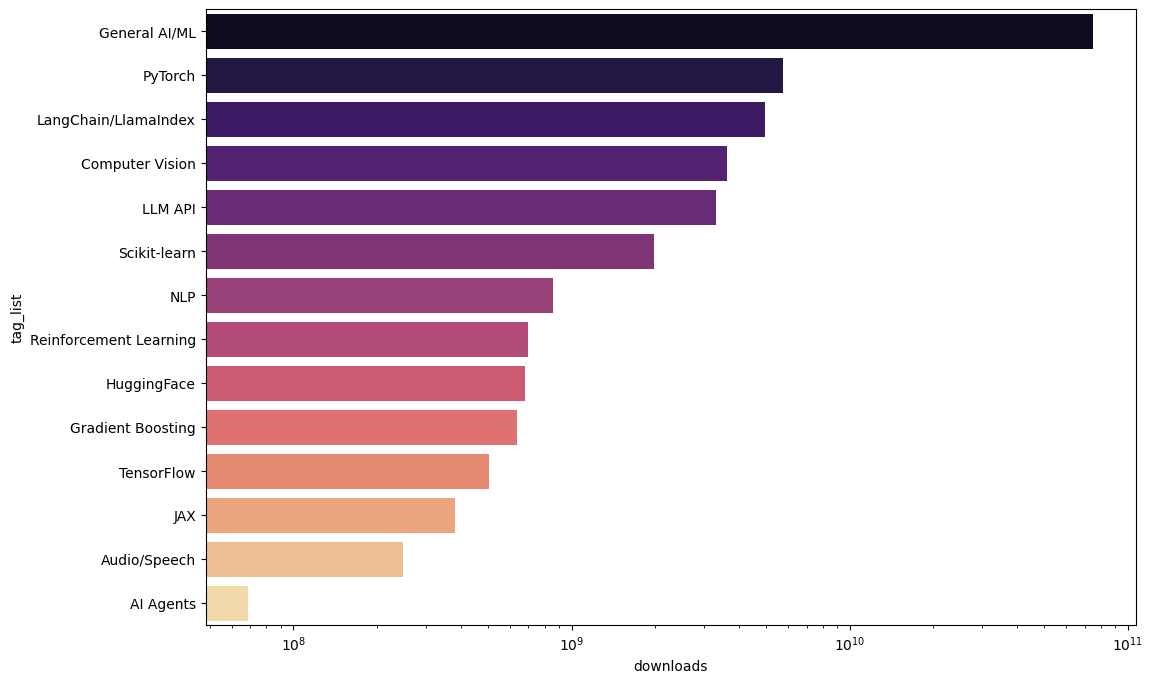

In [77]:
df['tag_list'] = df['framework_tag'].str.split(', ')
df_exploded = df.explode('tag_list')
tag_download = df_exploded.groupby('tag_list')['downloads'].sum().reset_index()
tag_download = tag_download.sort_values(by='downloads', ascending=False).head(15)
plt.figure(figsize=(12,8))
sns.barplot(data=tag_download, x='downloads', y='tag_list', palette='magma')
plt.xscale('log')
plt.show()

#### Key Takeaways:
- General AI/ML menjadi kategori dengan udungan terbanyak tapi ini merupakan kategori yang sangat luas dan tidak spesifik.
- Jadi  `PyTorch`, `LangChain/LlamaIndex`, dan `Computer Vision` adalah framework yang paling banyak diunduh, menunjukkan bahwa mereka adalah kategori populer di kalangan pengembang AI/ML.

## Pertumbuhan Download Package LLM-era vs Pre-LLM

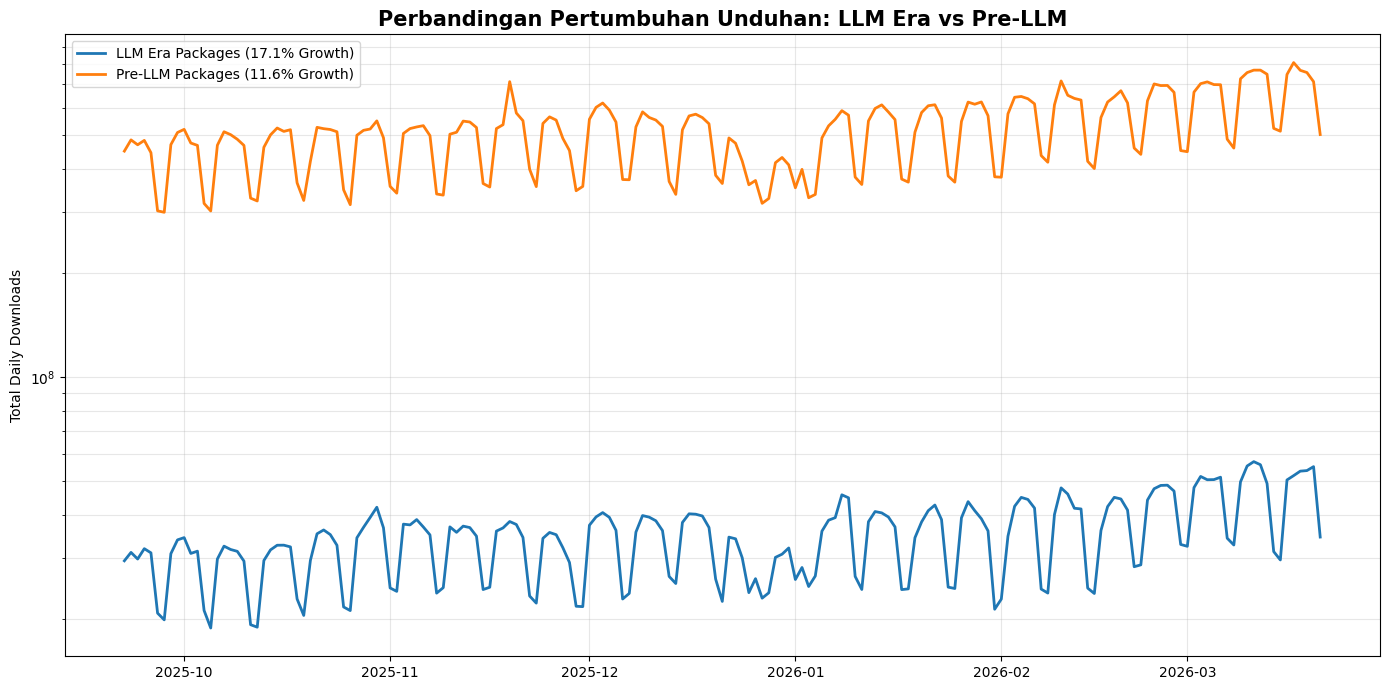

In [ ]:
llm_era = df[df['llm_era_package'] == True]
pre_llm = df[df['llm_era_package'] == False]

start_date = df['date'].min()
end_date = df['date'].max()

def get_growth_stats(data):
    start_val = data[data['date'] == start_date]['downloads'].sum()
    end_val = data[data['date'] == end_date]['downloads'].sum()
    absolute_growth = end_val - start_val
    percentage_growth = (absolute_growth / start_val) * 100 if start_val > 0 else 0
    return start_val, end_val, percentage_growth

llm_start, llm_end, llm_growth = get_growth_stats(llm_era)
pre_start, pre_end, pre_growth = get_growth_stats(pre_llm)

df_exploded = df.copy()
df_exploded['tag_list'] = df_exploded['framework_tag'].str.split(', ')
df_exploded = df_exploded.explode('tag_list')

target_frameworks = df['framework_tag'].str.split(', ').explode().unique()
fw_growth = []

for fw in target_frameworks:
    fw_data = df_exploded[df_exploded['tag_list'] == fw]
    s, e, g = get_growth_stats(fw_data)
    fw_growth.append({'Framework': fw, 'Start Downloads': s, 'End Downloads': e, 'Growth %': g})

fw_growth_df = pd.DataFrame(fw_growth)

plt.figure(figsize=(14, 7))

daily_llm = llm_era.groupby('date')['downloads'].sum()
daily_pre = pre_llm.groupby('date')['downloads'].sum()

plt.plot(daily_llm.index, daily_llm.values, label=f'LLM Era Packages ({llm_growth:.1f}% Growth)', linewidth=2)
plt.plot(daily_pre.index, daily_pre.values, label=f'Pre-LLM Packages ({pre_growth:.1f}% Growth)', linewidth=2)

plt.title('Perbandingan Pertumbuhan Unduhan: LLM Era vs Pre-LLM', fontsize=15, fontweight='bold')
plt.ylabel('Total Daily Downloads')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()


#### Key Takeaways:
- Package LLM-era menunjukkan pertumbuhan yang jauh lebih tinggi dibandingkan dengan package pre-LLM, dengan pertumbuhan sekitar 17.1% untuk LLM-era dibandingkan dengan hanya 11.6% untuk pre-LLM, mengindikasikan bahwa era LLM telah secara signifikan mempercepat adopsi dan penggunaan package AI/ML di ekosistem Python.

## Pertumbuhan Download Framework

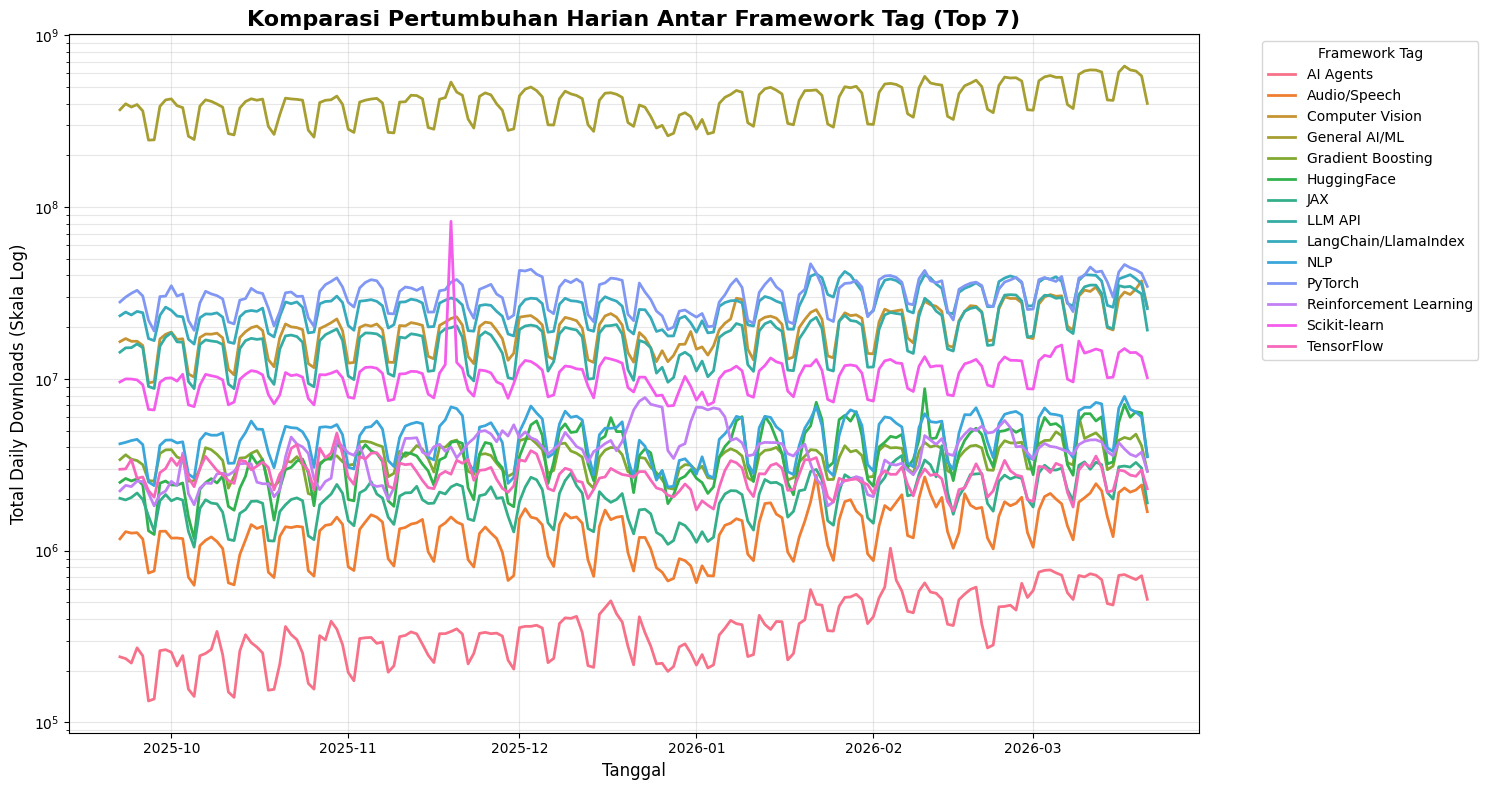

                 Framework  Start Downloads  End Downloads    Growth %
0                AI Agents           241045         520977  116.132672
2          Computer Vision         16461845       26182162   59.047555
1             Audio/Speech          1171989        1686533   43.903484
5              HuggingFace          2497105        3546564   42.027027
7                  LLM API         14292366       19244210   34.646776
11  Reinforcement Learning          2227985        2891307   29.772283
10                 PyTorch         28009047       34526568   23.269342
8     LangChain/LlamaIndex         23286707       25624664   10.039878
3            General AI/ML        368403035      401097140    8.874548
12            Scikit-learn          9594912       10163837    5.929445
6                      JAX          2017445        1895683   -6.035456
4        Gradient Boosting          3384363        2910666  -13.996637
9                      NLP          4188233        3520105  -15.952503
13    

In [ ]:
df_tags = df.copy()
df_tags['framework_tag'] = df_tags['framework_tag'].str.split(', ')
df_exploded = df_tags.explode('framework_tag')

top_tags = df_exploded.groupby('framework_tag')['downloads'].sum().index
df_top_tags = df_exploded[df_exploded['framework_tag'].isin(top_tags)]

daily_tag_growth = df_top_tags.groupby(['date', 'framework_tag'])['downloads'].sum().reset_index()


plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_tag_growth, x='date', y='downloads', hue='framework_tag', linewidth=2)

plt.title('Komparasi Pertumbuhan Harian Antar Framework Tag (Top 7)', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Daily Downloads (Skala Log)', fontsize=12)
plt.yscale('log') 
plt.legend(title='Framework Tag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

summary_list = []
start_date = daily_tag_growth['date'].min()
end_date = daily_tag_growth['date'].max()

for tag in top_tags:
    tag_data = daily_tag_growth[daily_tag_growth['framework_tag'] == tag]
    start_val = tag_data[tag_data['date'] == start_date]['downloads'].sum()
    end_val = tag_data[tag_data['date'] == end_date]['downloads'].sum()
    pct_change = ((end_val - start_val) / start_val) * 100 if start_val > 0 else 0
    summary_list.append({'Framework': tag, 'Start Downloads': start_val, 'End Downloads': end_val, 'Growth %': pct_change})

growth_summary = pd.DataFrame(summary_list).sort_values(by='Growth %', ascending=False)
print(growth_summary)

#### Key Takeaways:
- `AI Agents` merupakan framework dengan pertumbuhan sangat tinggi yaitu 116.132%, yang mana menunjukkan fase early adoption yang sangat masif.
- `Computer Vision` juga menunjukkan pertumbuhan yang sangat tinggi yaitu 59.04%, yang mungkin didorong oleh ekspansi penggunaan AI dalam industri atau automasi yang memanfaatkan kemampuan pengolahan gambar.
- `PyTorch` menunjukkan pertumbuhan yang cukup stabil yairu 29.77%.
- `NLP` menunjukkan penurunan pertumbuhan, mungkin dikarenakan pengguna beralih ke framework yang lebih spesifik seperti `LangChain/LlamaIndex` yang menunjukkan pertumbuhan 28.57%, menandakan bahwa banyak pengguna mungkin mencari solusi yang lebih terfokus untuk kebutuhan NLP mereka.

## Modeling Time Series: ARIMA, Prophet

03:56:06 - cmdstanpy - INFO - Chain [1] start processing
03:56:06 - cmdstanpy - INFO - Chain [1] done processing


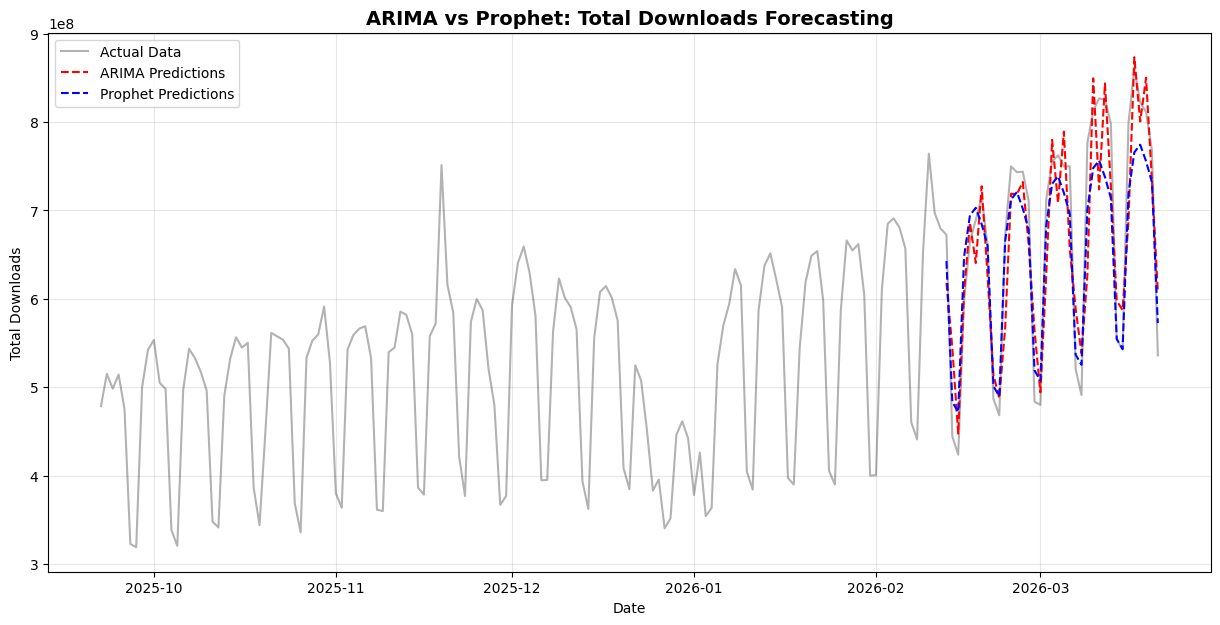

--- Error Analysis Comparison ---
               Model         RMSE          MAE  MAPE (%)
ARIMA (Walk-forward) 5.998618e+07 4.962822e+07  7.644369
             Prophet 4.559106e+07 3.857933e+07  5.623292


In [ ]:
df['ds'] = pd.to_datetime(df['date'])
df_daily = df.groupby('ds')['downloads'].sum().reset_index()

# Split data 80% train, 20% test
train_size = int(len(df_daily) * 0.8)
train, test = df_daily.iloc[:train_size], df_daily.iloc[train_size:]

# PROPHET MODEL 
prophet_train = train.rename(columns={'downloads': 'y'})
m_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
m_prophet.fit(prophet_train)

future = m_prophet.make_future_dataframe(periods=len(test))
forecast_prophet = m_prophet.predict(future)
prophet_preds = forecast_prophet.iloc[train_size:]['yhat'].values

# ARIMA MODEL 
# (p,d,q) : (5,1,0)  baseline 
history = [x for x in train['downloads']]
arima_preds = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arima_preds.append(yhat)
    history.append(test.iloc[t]['downloads']) 


plt.figure(figsize=(15, 7))
plt.plot(df_daily['ds'], df_daily['downloads'], label='Actual Data', color='black', alpha=0.3)
plt.plot(test['ds'], arima_preds, label='ARIMA Predictions', color='red', linestyle='--')
plt.plot(test['ds'], prophet_preds, label='Prophet Predictions', color='blue', linestyle='--')

plt.title('ARIMA vs Prophet: Total Downloads Forecasting', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Downloads')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Error Analysis
def calculate_errors(actual, predicted, name):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape * 100}

actual_vals = test['downloads'].values
error_arima = calculate_errors(actual_vals, arima_preds, 'ARIMA (Walk-forward)')
error_prophet = calculate_errors(actual_vals, prophet_preds, 'Prophet')

error_df = pd.DataFrame([error_arima, error_prophet])
print("--- Error Analysis Comparison ---")
print(error_df.to_string(index=False))

#### Key Takeaways:
- Model Prophet menunjukkan performa yang lebih baik dibandingkan dengan ARIMA dalam memprediksi tren download harian, dengan MAPE sevesar 5.623% sedangkan ARIMA memilik MAPE sebesar 7.644% yang menunjukkan bahwa Prophet lebih mampu menangkap pola musiman dan tren dalam data download harian dibandingkan dengan ARIMA.
- Model ARIMA mungkin dapat ditingkatkan dengan melakukan hyperparameter tuning untuk menemukan nilai p, d, q yang optimal, atau dengan menggunakan model yang lebih kompleks seperti SARIMA untuk menangkap pola musiman yang lebih baik. 
- Kesalahan di bawah 10% dapat dikategorikan sebagai prediksi yang sangat akurat untuk data dunia nyata yang memiliki volatilitas tinggi seperti jumlah download harian ini.

## Prediksi Download Harian Untuk 30 Hari ke Depan

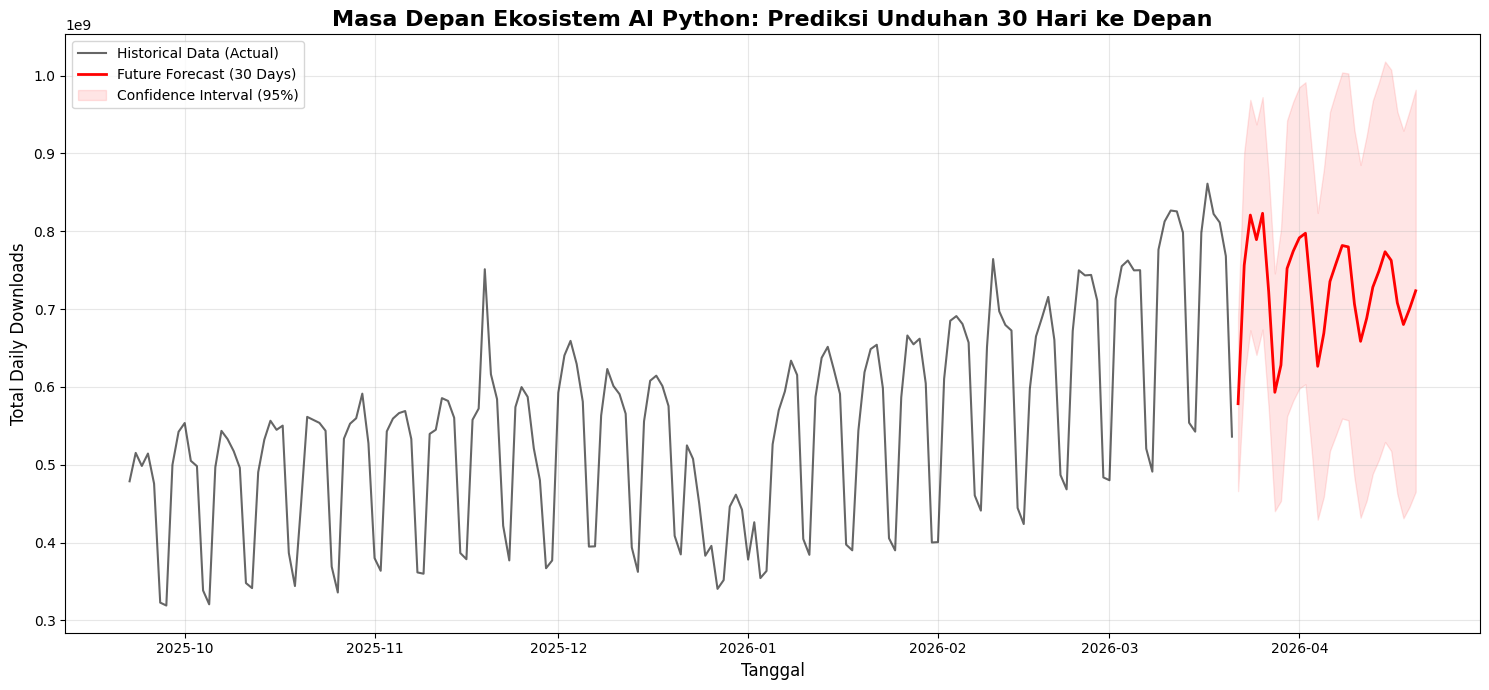

Rata-rata unduhan harian saat ini (7 hari terakhir): 734,214,953
Rata-rata proyeksi unduhan harian (30 hari ke depan): 725,656,971
Proyeksi pertumbuhan jangka pendek: -1.17%


In [ ]:
df_daily = df.groupby('date')['downloads'].sum().sort_index()

model = ARIMA(df_daily.values, order=(5, 1, 0))
model_fit = model.fit()

forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.summary_frame()['mean']
forecast_ci_lower = forecast.summary_frame()['mean_ci_lower']
forecast_ci_upper = forecast.summary_frame()['mean_ci_upper']


last_date = df_daily.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

plt.figure(figsize=(15, 7))
plt.plot(df_daily.index, df_daily.values, label='Historical Data (Actual)', color='black', alpha=0.6)
plt.plot(future_dates, forecast_mean, label='Future Forecast (30 Days)', color='red', linewidth=2)
plt.fill_between(future_dates, forecast_ci_lower, forecast_ci_upper, color='red', alpha=0.1, label='Confidence Interval (95%)')

plt.title('Masa Depan Ekosistem AI Python: Prediksi Unduhan 30 Hari ke Depan', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Daily Downloads', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

current_avg = df_daily.tail(7).mean()
forecast_avg = forecast_mean.mean()
growth_projection = ((forecast_avg - current_avg) / current_avg) * 100

print(f"Rata-rata unduhan harian saat ini (7 hari terakhir): {current_avg:,.0f}")
print(f"Rata-rata proyeksi unduhan harian (30 hari ke depan): {forecast_avg:,.0f}")
print(f"Proyeksi pertumbuhan jangka pendek: {growth_projection:.2f}%")

#### Key Takeaways:
- Download harian diprediksi akan terjaga di kisaran 725 juta per hari untuk 30 hari ke depan.
- Terdapat sedikit penurunan pertumbuhan sekitar -1,17% dibandingkan pertumbuhan yang tinggi di akhir bukan Maret.
- Penurunan rutin akan tetap terjadi setiap akhir pekan, menunjukkan bahwa pola kerja engineer atau sistem otomasi tidak banyak berubah dalam waktu dekat.
- Adanya potensi variasi yang cukup besar di masa depan. Ada peluang bagi ekosistem untuk menembus angka 900 juta hingga 1 miliar unduhan harian jika terjadi rilis model AI besar yang baru.

## Kesimpulan / Hasil Analisis dari Tujuan Bisnis
1. **Prediksi trajektori download package AI** 
   - Model Prophet menunjukkan performa yang lebih baik dibandingkan dengan ARIMA dalam memprediksi tren download harian, dengan MAPE sebesar 5.623% sedangkan ARIMA memilik MAPE sebesar 7.644%.
   - Volume download harian diprediksi akan stabil di angka 725 juta per hari pada April 2026.
2. **Identifikasi framework AI yang tumbuh paling cepat**
   - `AI Agents` merupakan framework dengan pertumbuhan sangat tinggi yaitu 116.132%, yang mana menunjukkan fase early adoption yang sangat masif dan mungkin peralihan dari AI generatif ke sistem AI otonom yang mampu mengambil tindakan sendiri.
   - `Computer Vision` juga menunjukkan pertumbuhan yang sangat tinggi yaitu 59.04%, yang mungkin didorong oleh ekspansi penggunaan AI dalam industri atau automasi yang memanfaatkan kemampuan pengolahan gambar.
   - `PyTorch` menunjukkan pertumbuhan yang stabil karena masih menjadi backbone utama untuk banyak framework AI/ML lainnya.
3. **Kuantifikasi dampak era LLM terhadap ekosistem Python**
   - Package LLM-era (rilis setelah 2023) menunjukkan pertumbuhan yang jauh lebih tinggi dibandingkan dengan package pre-LLM, dengan pertumbuhan sekitar 17.1% untuk LLM-era dibandingkan dengan hanya 11.6% untuk pre-LLM, mengindikasikan bahwa era LLM telah secara signifikan mempercepat adopsi dan penggunaan package AI/ML di ekosistem Python.
   - Penurunan pertumbuhan pada package NLP mungkin menunjukkan efek peralihan pengguna ke framework yang lebih spesifik seperti `LangChain/LlamaIndex` yang menunjukkan pertumbuhan 28.57%, menandakan bahwa banyak pengguna mungkin mencari solusi yang lebih terfokus untuk kebutuhan NLP mereka.
4. **Analisis pola harian dan mingguan**
   - Terdapat pola 7 harian yang sangat kaku. Puncak download terjadi pada Selasa dan Rabu (hari kerja) dan menurun tajam hingga hingga 40% pada hari Sabtu dan Minggu.
   - Terjadi penurunan masif selama periode Natal dan Tahun Baru. Hal ini menunjukkan bahwa banyak pengguna atau sistem automasi mungkin tidak terlalu aktif dalam mengunduh package selama periode tersebut, yang dapat menjadi pertimbangan penting untuk perencanaan rilis atau kampanye promosi di masa depan.